## Sensorial Analysis for Multimodal Modeling

- Understand ET, HR, EEG 
- Measure relation between labels (Hard, Soft)
- Detect if they add value or just noise
- Define how to add them to our multimodal pipeline

In [73]:
#Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from scipy.stats import mannwhitneyu
import os

os.chdir("/Users/diego/Desktop/Master Neuro/M2/Internship_Valencia/multimodal-exist/")

In [7]:
#Load Data
df = pd.read_parquet("./data/processed/train.parquet")
df.head()

,id,lang,text,image_file,split,ET_raw,HR_raw,EEG_raw,task21_hard,task21_valid_hard,task21_soft,task22_hard,task22_valid_hard,task22_soft,task23_hard,task23_valid_hard,task23_soft,task23_num_hard_labels
0,110887,es,A VECES QUISIERAIR/ALZUMBA www.facebook.com/Oi...,110887.jpeg,Train,"{'EN1': None, 'EN2': None, 'EN3': None, 'EN4':...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN4':...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN5':...",1,True,1.000000,1.0,True,0.833333,"{'IDEOLOGICAL-INEQUALITY': 0, 'MISOGYNY-NON-SE...",True,{'IDEOLOGICAL-INEQUALITY': 0.16666666666666666...,2
1,110466,es,Se necesita cuidadora para adulto mayor.... fo...,110466.jpeg,Train,"{'EN1': None, 'EN2': None, 'EN3': None, 'EN4':...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN4':...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN5':...",1,True,0.500000,1.0,True,1.000000,"{'IDEOLOGICAL-INEQUALITY': 0, 'MISOGYNY-NON-SE...",True,{'IDEOLOGICAL-INEQUALITY': 0.16666666666666666...,2
2,111269,es,tomboy como son el anime y manga pre to tomboy...,111269.jpeg,Train,"{'EN1': None, 'EN2': None, 'EN3': None, 'EN4':...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN4':...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN5':...",1,True,0.833333,1.0,True,1.000000,"{'IDEOLOGICAL-INEQUALITY': 0, 'MISOGYNY-NON-SE...",True,"{'IDEOLOGICAL-INEQUALITY': 0.0, 'MISOGYNY-NON-...",1
3,110593,es,HOY QUIERO FELICITAR A TODAS LAS MUJERES DE ES...,110593.jpeg,Train,"{'EN1': None, 'EN2': None, 'EN3': None, 'EN4':...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN4':...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN5':...",0,True,0.166667,0.0,True,0.000000,"{'IDEOLOGICAL-INEQUALITY': 0, 'MISOGYNY-NON-SE...",False,"{'IDEOLOGICAL-INEQUALITY': 0.0, 'MISOGYNY-NON-...",0
4,110946,es,DUCHATE GUARRA GRACIAS memegenerator.es,110946.jpeg,Train,"{'EN1': None, 'EN2': None, 'EN3': None, 'EN4':...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN4':...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN5':...",1,True,0.666667,1.0,True,1.000000,"{'IDEOLOGICAL-INEQUALITY': 0, 'MISOGYNY-NON-SE...",True,"{'IDEOLOGICAL-INEQUALITY': 0.0, 'MISOGYNY-NON-...",1


## Eye Tracking

This datasets records oculomotor events: fixations (pauses where the eye gathers information) and saccades (rapid movements between fixations),
to reveal what elements on an interface capture a user’s attention and for how long.
Additional metrics, such as pupil dilation, are closely correlated with cognitive load and
emotional arousal.

In [25]:
#We first flatten the ET features, which are stored as dictionaries in the "ET_raw" column.
# Each dictionary contains user-specific features, and we want to create a new DataFrame where each row corresponds to a user and includes both the labels and the ET features.
def flatten_et(df):
    rows = []
    
    for _, row in df.iterrows():
        et = row["ET_raw"]
        if not isinstance(et, dict):
            continue
        for user, feats in et.items():
            if not isinstance(feats, dict):
                continue
            
            new_row = {
                "id": row["id"],
                "user": user,
                
                # labels
                "task21_hard": row["task21_hard"],
                "task22_hard": row["task22_hard"],
                "task22_valid": row["task22_valid_hard"],
                "task23_hard": row["task23_hard"],
                
                # features ET
                **feats}
            
            rows.append(new_row)
    
    return pd.DataFrame(rows)

et_df = flatten_et(df)
et_df.head(3)

,id,user,task21_hard,task22_hard,task22_valid,task23_hard,3d_eye_states_pupil diameter left [mm]_max,3d_eye_states_pupil diameter left [mm]_mean,3d_eye_states_pupil diameter left [mm]_min,3d_eye_states_pupil diameter left [mm]_std,...,fixations_duration_max_ns,fixations_duration_mean_ns,fixations_duration_min_ns,fixations_duration_std_ns,reaction_time,saccades_count,saccades_duration_max_ns,saccades_duration_mean_ns,saccades_duration_min_ns,saccades_duration_std_ns
0,110887,ES1,1,1.0,True,"{'IDEOLOGICAL-INEQUALITY': 0, 'MISOGYNY-NON-SE...",3.0798,2.7610,1.7061,0.1419,...,1.030753e+09,3.233163e+08,1.017532e+08,2.324247e+08,10080.0059,28.3084,3.251362e+08,6.645716e+07,1.676691e+07,7.890163e+07
1,110887,ES2,1,1.0,True,"{'IDEOLOGICAL-INEQUALITY': 0, 'MISOGYNY-NON-SE...",4.1210,3.6960,3.2277,0.1528,...,1.026000e+09,2.577915e+08,7.512499e+07,1.736528e+08,16708.0000,57.0000,1.651261e+08,3.941896e+07,9.992960e+06,2.909943e+07
2,110466,ES1,1,1.0,True,"{'IDEOLOGICAL-INEQUALITY': 0, 'MISOGYNY-NON-SE...",4.2079,2.7497,1.7904,0.2256,...,1.351250e+09,2.489633e+08,6.999910e+07,2.206639e+08,23014.0000,70.0000,5.555000e+08,7.757828e+07,9.999872e+06,1.060905e+08


In [116]:
# We clean the ET features and convert them to more interpretable units.

# Reaction time (ms to s)
et_df["reaction_time_s"] = et_df["reaction_time"] / 1000

# We remove absurd values (optional)
et_df = et_df[et_df["reaction_time_s"] < 60]

# Blink duration (ns to ms)
et_df["blink_duration_ms"] = et_df["blinks_duration_mean_ns"] / 1e6

# Fixation duration (ns to ms)
et_df["fixation_duration_ms"] = et_df["fixations_duration_mean_ns"] / 1e6

#Pupil mean
et_df['pupil_mean_left'] = et_df["3d_eye_states_pupil diameter left [mm]_mean"]
et_df['pupil_mean_right'] = et_df["3d_eye_states_pupil diameter right [mm]_mean"]
et_df["pupil_mean"] = (et_df["3d_eye_states_pupil diameter left [mm]_mean"] + et_df["3d_eye_states_pupil diameter right [mm]_mean"]) / 2

# Extra
et_df["fixations"] = et_df["fixations_count"]
et_df["saccades"] = et_df["saccades_count"]

et_df.head(3)

,id,user,task21_hard,task22_hard,task22_valid,task23_hard,3d_eye_states_pupil diameter left [mm]_max,3d_eye_states_pupil diameter left [mm]_mean,3d_eye_states_pupil diameter left [mm]_min,3d_eye_states_pupil diameter left [mm]_std,...,saccades,class_IDEOLOGICAL-INEQUALITY,class_MISOGYNY-NON-SEXUAL-VIOLENCE,class_OBJECTIFICATION,class_SEXUAL-VIOLENCE,class_STEREOTYPING-DOMINANCE,fixation_duration_ms,pupil_mean,pupil_mean_left,pupil_mean_right
0,110887,ES1,1,1.0,True,"{'IDEOLOGICAL-INEQUALITY': 0, 'MISOGYNY-NON-SE...",3.0798,2.7610,1.7061,0.1419,...,28.3084,0,1,1,0,0,323.316278,2.70620,2.7610,2.6514
1,110887,ES2,1,1.0,True,"{'IDEOLOGICAL-INEQUALITY': 0, 'MISOGYNY-NON-SE...",4.1210,3.6960,3.2277,0.1528,...,57.0000,0,1,1,0,0,257.791510,3.60115,3.6960,3.5063
2,110466,ES1,1,1.0,True,"{'IDEOLOGICAL-INEQUALITY': 0, 'MISOGYNY-NON-SE...",4.2079,2.7497,1.7904,0.2256,...,70.0000,0,0,0,1,1,248.963299,2.64390,2.7497,2.5381


## Physiological Feature Selection and Expected Behavioral Patterns

We selected a set of eye-tracking features that capture complementary aspects of cognitive processing, visual attention, and physiological arousal during meme exposure. These indicators are used in cognitive neuroscience and human-computer interaction to quantify how individuals perceive and process visual stimuli.

SELECTED FEATURES:

1. **Reaction Time (s):** Measures the latency between stimulus presentation and the participant’s response. It reflects cognitive processing load and decision complexity.

2. **Fixation Count:** Represents the number of fixations during stimulus exposure. It serves as a proxy for visual attention allocation and information.

3. **Fixation Duration (ms):** Captures the average duration of fixations,this indicates depth of processing and sustained attention on specific regions.

4. **Blink Duration (ms):** Associated with cognitive state regulation (Fatigue, cognitive load, and attentional disengagement).

5. **Pupil Diameter (left, right, mean):** A measure of physiological arousal and cognitive effort, linked to activity in the nervous system.

6. **Saccades Count:** Reflects rapid eye movements between fixations, capturing visual exploration behavior and scanning patterns.




## Expected Behavioral Differences (Sexist vs Non-Sexist Memes)

We have the hypotesis that sexist content induces measurable changes across these physiological signals due to increased cognitive and emotional engagement:

- **Reaction Time:** Expected to be `higher` for sexist memes. They may require additional cognitive evaluation, interpretation, or emotional processing.

- **Fixation Count:** Likely `higher` in sexist content, reflecting increased attention and visual inspection.

- **Fixation Duration:** Expected to `increase`, indicating deeper semantic or emotional processing of the content.

- **Pupil Diameter:** Anticipated to be `larger in sexist memes`, suggesting elevated arousal or cognitive effort.

- **Saccades:** May `increase or reorganize`, reflecting more active visual exploration when processing complex or provocative stimuli.

- **Blink Duration:** Expected to show `subtle changes`, potentially decreasing under high attention or increasing under cognitive load.

---

By combining these features, we capture multiple dimensions of human perception:

- **Cognitive Load** $\rightarrow$ reaction time, blink behavior
- **Attention Allocation** $\rightarrow$ fixations, saccades
- **Depth of Processing** $\rightarrow$ fixation duration
- **Physiological Arousal** $\rightarrow$ pupil dilation


In [103]:
#Function to compute the table of results for a given metric, comparing two groups (e.g., "task21_hard" vs "task22_hard") using mean ± std and Mann-Whitney U test for p-values.
def compute_table(df, group_col, group_names, metrics):
    
    results = []
    
    g1, g2 = group_names
    
    df1 = df[df[group_col] == g1]
    df2 = df[df[group_col] == g2]
    
    for m in metrics:
        
        x = df1[m].dropna()
        y = df2[m].dropna()
        
        # mean ± std
        mean1, std1 = x.mean(), x.std()
        mean2, std2 = y.mean(), y.std()
        
        # Mann-Whitney
        if len(x) > 0 and len(y) > 0:
            stat, p = mannwhitneyu(x, y, alternative='two-sided')

            if p < 0.05:
                p_formatted = f"{p:.4f}*"
            else:
                p_formatted = f"{p:.4f}"
        else:
            p_formatted = np.nan
        
        results.append({
            "Metric": m,
            f"{g1}": f"{mean1:.2f} ± {std1:.2f}",
            f"{g2}": f"{mean2:.2f} ± {std2:.2f}",
            "p-value": p_formatted})
    
    return pd.DataFrame(results)

### Task 2.1 (Sexist or Not-Sexist)

In [112]:
metrics = ["reaction_time_s", "fixations", "fixation_duration_ms", 
           "blink_duration_ms","pupil_mean_left","pupil_mean_right",
           "pupil_mean","saccades"]
table_task21 = compute_table(
    et_df,
    group_col="task21_hard",
    group_names=(0, 1),  # 0 = non-sexist, 1 = sexist
    metrics=metrics)

table_task21.columns = ["Metric", "Non-Sexist (0)", "Sexist (1)", "p-value"]
table_task21

,Metric,Non-Sexist (0),Sexist (1),p-value
0,reaction_time_s,13.07 ± 7.79,15.04 ± 8.42,0.0000*
1,fixations,38.62 ± 24.51,42.61 ± 26.20,0.0000*
2,fixation_duration_ms,273.99 ± 91.05,287.75 ± 109.26,0.0000*
3,blink_duration_ms,263.83 ± 54.41,258.55 ± 50.82,0.0026*
4,pupil_mean_left,3.14 ± 0.41,3.14 ± 0.42,0.8559
5,pupil_mean_right,3.12 ± 0.39,3.13 ± 0.39,0.3206
6,pupil_mean,3.13 ± 0.38,3.13 ± 0.38,0.6906
7,saccades,37.88 ± 24.51,41.80 ± 26.25,0.0000*


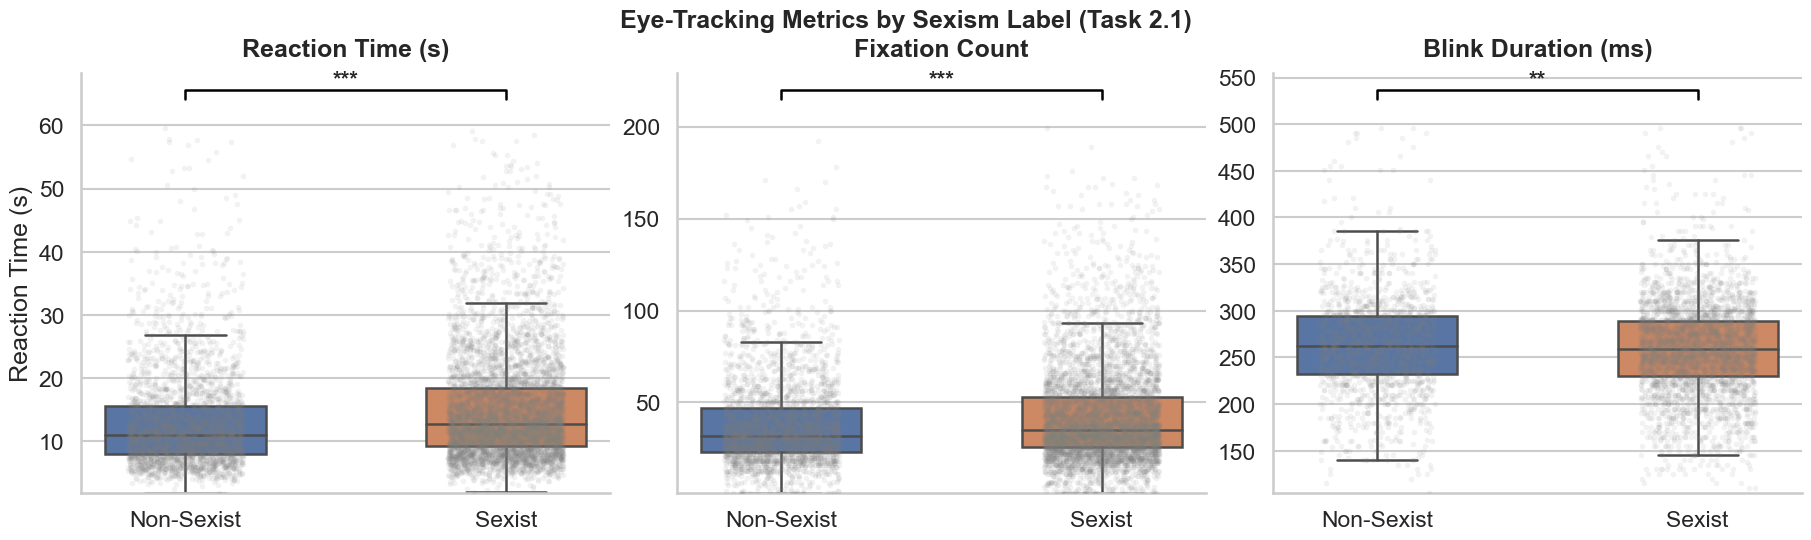

In [115]:
#Boxplots compared by task21_hard (sexism label) for the selected metrics, with significance annotations based on Mann-Whitney U test.
metrics = ["reaction_time_s", "fixations", "blink_duration_ms"]  
label_map = {0: "Non-Sexist",1: "Sexist"}

plot_df = et_df.copy()
plot_df["task21_label"] = plot_df["task21_hard"].map(label_map)
order = ["Non-Sexist", "Sexist"]

#Plot
sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

def add_significance(ax, data, x_col, y_col, order):
    # Extract groups without NaNs
    g1 = data.loc[data[x_col] == order[0], y_col].dropna()
    g2 = data.loc[data[x_col] == order[1], y_col].dropna()

    if len(g1) < 2 or len(g2) < 2:
        return None

    #  Mann-Whitney U test
    stat, p = mannwhitneyu(g1, g2, alternative="two-sided")
    if p < 0.001:
        stars = "***"
    elif p < 0.01:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = "ns"

    y_max = data[y_col].dropna().max()
    y_min = data[y_col].dropna().min()
    h = (y_max - y_min) * 0.08 if y_max > y_min else 0.5
    y = y_max + h

   
    ax.plot([0, 0, 1, 1], [y, y+h*0.3, y+h*0.3, y], lw=1.8, c="black")
    ax.text(0.5, y+h*0.35, stars, ha="center", va="bottom", fontsize=16, fontweight="bold")
    ax.set_ylim(y_min, y + h*0.9)

    return p

for ax, m in zip(axes, metrics):
    sub = plot_df[["task21_label", m]].dropna()

    sns.boxplot(data=sub,x="task21_label",y=m,order=order,ax=ax,width=0.5,showfliers=False,linewidth=1.8)
    sns.stripplot(data=sub,x="task21_label",y=m,order=order,ax=ax,color="grey",alpha=0.1,size=4,jitter=0.18)

    add_significance(ax, sub, "task21_label", m, order)

    
    titles = {"reaction_time_s": "Reaction Time (s)",
        "blink_duration_ms": "Blink Duration (ms)",
        "fixations": "Fixation Count",
        "saccades": "Saccade Count"}.get(m, m)

    ax.set_title(titles, fontweight="bold", pad=12)
    ax.set_xlabel("")
    ax.set_ylabel(titles if ax == axes[0] else "")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Eye-Tracking Metrics by Sexism Label (Task 2.1)", fontsize=18, fontweight="bold", y=1.05)
plt.show()

### Task 2.2 (Judgemental or Direct)

In [113]:
et_task22 = et_df[et_df["task21_hard"] == 1]

table_task22 = compute_table(
    et_task22,
    group_col="task22_hard",
    group_names=(0, 1),  # 0 = judgemental, 1 = direct
    metrics=metrics)
table_task22.columns = ["Metric", "Judgemental", "Direct", "p-value"]
table_task22

,Metric,Judgemental,Direct,p-value
0,reaction_time_s,16.31 ± 9.19,14.66 ± 8.13,0.0000*
1,fixations,46.60 ± 28.82,41.40 ± 25.23,0.0000*
2,fixation_duration_ms,289.63 ± 121.20,287.18 ± 105.40,0.9566
3,blink_duration_ms,259.93 ± 48.05,258.13 ± 51.64,0.3328
4,pupil_mean_left,3.12 ± 0.39,3.14 ± 0.43,0.3739
5,pupil_mean_right,3.12 ± 0.38,3.13 ± 0.40,0.5829
6,pupil_mean,3.12 ± 0.36,3.14 ± 0.38,0.4371
7,saccades,45.86 ± 28.83,40.57 ± 25.30,0.0000*


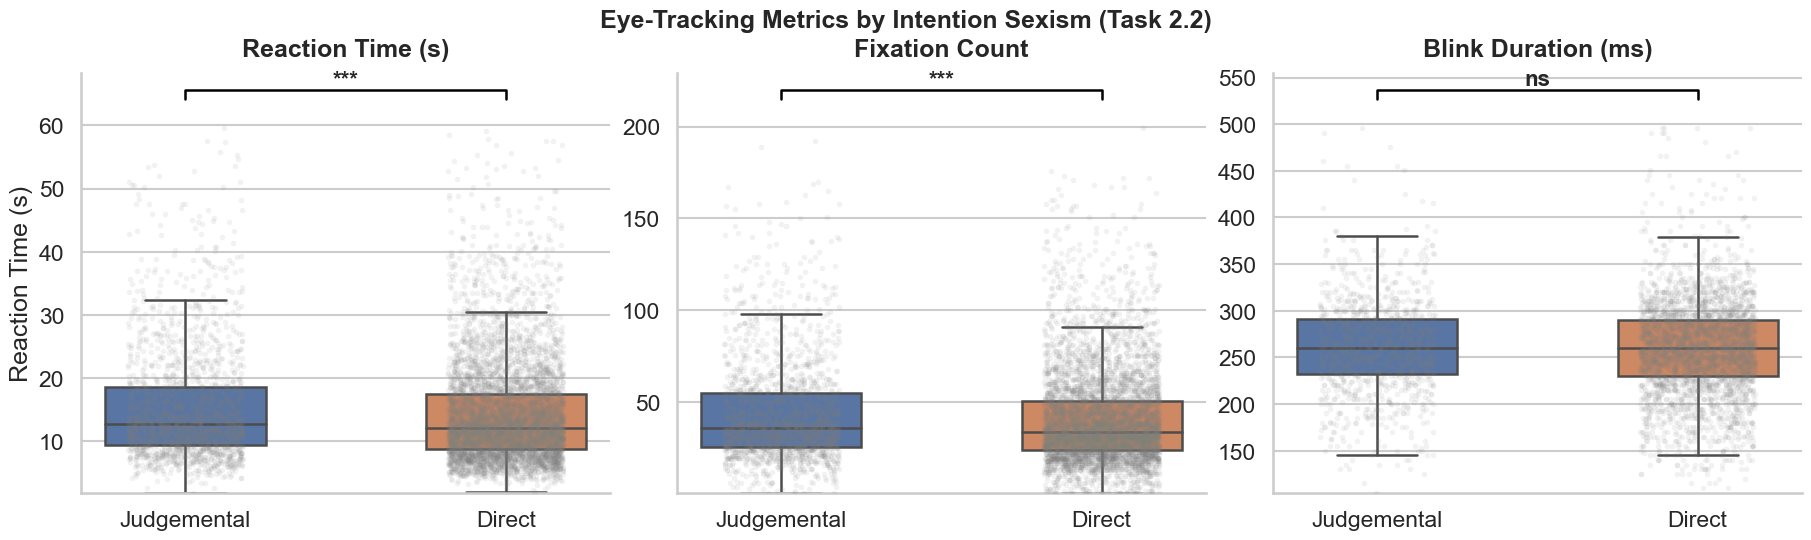

In [95]:
#Boxplots compared by task21_hard (sexism label) for the selected metrics, with significance annotations based on Mann-Whitney U test.
metrics = ["reaction_time_s", "fixations", "blink_duration_ms"]  
label_map = {0: "Judgemental",1: "Direct"}

plot_df = et_df.copy()
plot_df["task22_label"] = plot_df["task22_hard"].map(label_map)
order = ["Judgemental", "Direct"]

#Plot
sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)


def add_significance(ax, data, x_col, y_col, order):
    # Extract groups without NaNs
    g1 = data.loc[data[x_col] == order[0], y_col].dropna()
    g2 = data.loc[data[x_col] == order[1], y_col].dropna()

    if len(g1) < 2 or len(g2) < 2:
        return None

    #  Mann-Whitney U test
    stat, p = mannwhitneyu(g1, g2, alternative="two-sided")
    if p < 0.001:
        stars = "***"
    elif p < 0.01:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = "ns"

    y_max = data[y_col].dropna().max()
    y_min = data[y_col].dropna().min()
    h = (y_max - y_min) * 0.08 if y_max > y_min else 0.5
    y = y_max + h

   
    ax.plot([0, 0, 1, 1], [y, y+h*0.3, y+h*0.3, y], lw=1.8, c="black")
    ax.text(0.5, y+h*0.35, stars, ha="center", va="bottom", fontsize=16, fontweight="bold")
    ax.set_ylim(y_min, y + h*0.9)

    return p

for ax, m in zip(axes, metrics):
    sub = plot_df[["task22_label", m]].dropna()

    sns.boxplot(data=sub,x="task22_label",y=m,order=order,ax=ax,width=0.5,showfliers=False,linewidth=1.8)
    sns.stripplot(data=sub,x="task22_label",y=m,order=order,ax=ax,color="grey",alpha=0.1,size=4,jitter=0.18)

    add_significance(ax, sub, "task22_label", m, order)

    
    titles = {"reaction_time_s": "Reaction Time (s)",
        "blink_duration_ms": "Blink Duration (ms)",
        "fixations": "Fixation Count",
        "saccades": "Saccade Count"}.get(m, m)

    ax.set_title(titles, fontweight="bold", pad=12)
    ax.set_xlabel("")
    ax.set_ylabel(titles if ax == axes[0] else "")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Eye-Tracking Metrics by Intention Sexism (Task 2.2)", fontsize=18, fontweight="bold", y=1.05)
plt.show()

### Task 2.3 (Multilabel)

In [114]:
task23_classes = list(df["task23_hard"].iloc[0].keys())

tables_task23 = {}

for cls in task23_classes:
    
    et_df[f"class_{cls}"] = et_df["task23_hard"].apply(lambda x: x.get(cls, 0))
    
    table = compute_table(
        et_df,
        group_col=f"class_{cls}",
        group_names=(0, 1),
        metrics=metrics
    )
    
    table.columns = ["Metric", "Absent", "Present", "p-value"]
    
    tables_task23[cls] = table

for t in task23_classes:
    print(f"Class {t}:\n")
    print(tables_task23[t])
    print("\n\n")

Class IDEOLOGICAL-INEQUALITY:

                 Metric           Absent          Present  p-value
0       reaction_time_s     13.61 ± 7.84     16.43 ± 9.00  0.0000*
1             fixations    39.20 ± 24.59    46.85 ± 27.79  0.0000*
2  fixation_duration_ms  281.85 ± 104.22  286.19 ± 101.67  0.0432*
3     blink_duration_ms   261.07 ± 52.79   258.27 ± 50.20   0.1184
4       pupil_mean_left      3.14 ± 0.42      3.14 ± 0.41   0.9583
5      pupil_mean_right      3.13 ± 0.39      3.12 ± 0.39   0.8753
6            pupil_mean      3.13 ± 0.38      3.13 ± 0.37   0.7588
7              saccades    38.44 ± 24.60    45.97 ± 27.88  0.0000*



Class MISOGYNY-NON-SEXUAL-VIOLENCE:

                 Metric           Absent          Present  p-value
0       reaction_time_s     14.21 ± 8.15     15.57 ± 8.98  0.0000*
1             fixations    40.90 ± 25.33    43.94 ± 28.34  0.0022*
2  fixation_duration_ms  282.39 ± 102.64  287.93 ± 110.56   0.2396
3     blink_duration_ms   261.38 ± 52.34   251.60 ± 49.14 

Eye-tracking signals reveal that sexist content is not only visually perceived but cognitively processed with higher complexity. Features related to attention allocation and exploration (fixations, saccades) consistently show significant differences, while physiological arousal (pupil dilation) remains almost unchanged. This suggests that the detection of sexism relies more on cognitive interpretation than emotional reactivity.

## Heart Rate (HR)

To further investigate the physiological response to sexist content, we analyze heart rate (HR) signals as an additional modality reflecting nervous system activity. Heart rate dynamics are commonly associated with emotional arousal, stress responses, and cognitive engagement, making them a relevant signal for understanding how users react to potentially provocative or sensitive stimuli such as sexist memes.

SELECTED FEATURES

1. **HR Mean (beats per minute):** Represents the average heart rate during stimulus exposure.

2. **HR Max (beats per minute):** Captures peak heart rate.
3. **HR Min (beats per minute):** Reflects the lowest heart rate during exposure.

---

### Expected Behavioral Differences

We hypothesize that exposure to sexist content may induce measurable changes in heart rate patterns due to increased emotional or cognitive engagement:

- **HR Mean / HR Max:** Expected to be `higher for sexist memes`, reflecting elevated arousal or stress.

- **HR Min:** Not expected to show strong discriminative power, but included for completeness.

In [126]:
#We flatten the HR as we did with the ET, to have a more interpretable format for the HR features as well.
def flatten_hr(df):
    rows = []
    
    for _, row in df.iterrows():
        hr = row["HR_raw"]
        if not isinstance(hr, dict):
            continue
        for user, feats in hr.items():
            if not isinstance(feats, dict):
                continue
            
            new_row = {
                "id": row["id"],
                "user": user,
                
                # labels
                "task21_hard": row["task21_hard"],
                "task22_hard": row["task22_hard"],
                "task22_valid": row["task22_valid_hard"],
                "task23_hard": row["task23_hard"],
                
                # features ET
                **feats}
            
            rows.append(new_row)
    
    return pd.DataFrame(rows)

hr_df = flatten_hr(df)

#Format Columns
hr_df["heart_rate_max"] = hr_df["garmin_hr_max"].astype(float)
hr_df["heart_rate_min"] = hr_df["garmin_hr_min"].astype(float)
hr_df["heart_rate_mean"] = hr_df["garmin_hr_mean"].astype(float)

hr_df.drop(["garmin_hr_max", "garmin_hr_min", "garmin_hr_mean","garmin_hr_std"], axis=1, inplace=True)

hr_df.head(3)

,id,user,task21_hard,task22_hard,task22_valid,task23_hard,heart_rate_max,heart_rate_min,heart_rate_mean
0,110887,ES1,1,1.0,True,"{'IDEOLOGICAL-INEQUALITY': 0, 'MISOGYNY-NON-SE...",68.2535,62.6781,65.5112
1,110887,ES2,1,1.0,True,"{'IDEOLOGICAL-INEQUALITY': 0, 'MISOGYNY-NON-SE...",61.0000,59.0000,59.7647
2,110466,ES1,1,1.0,True,"{'IDEOLOGICAL-INEQUALITY': 0, 'MISOGYNY-NON-SE...",61.0000,57.0000,59.3913


### Task 2.1 (Sexist or Not-Sexist)

In [129]:
metrics = ['heart_rate_max', 'heart_rate_min', 'heart_rate_mean']

table_task21 = compute_table(
    hr_df,
    group_col="task21_hard",
    group_names=(0, 1),  # 0 = non-sexist, 1 = sexist
    metrics=metrics)

table_task21.columns = ["Metric", "Non-Sexist (0)", "Sexist (1)", "p-value"]
table_task21

,Metric,Non-Sexist (0),Sexist (1),p-value
0,heart_rate_max,71.67 ± 12.25,71.56 ± 11.88,0.8755
1,heart_rate_min,67.66 ± 11.69,67.20 ± 11.38,0.0918
2,heart_rate_mean,69.66 ± 11.90,69.37 ± 11.56,0.3399


### Task 2.2 (Intention)

In [130]:
hr_task22 = hr_df[hr_df["task21_hard"] == 1]

table_task22 = compute_table(
    hr_task22,
    group_col="task22_hard",
    group_names=(0, 1),  # 0 = judgemental, 1 = direct
    metrics=metrics)
table_task22.columns = ["Metric", "Judgemental", "Direct", "p-value"]
table_task22

,Metric,Judgemental,Direct,p-value
0,heart_rate_max,72.46 ± 12.43,71.28 ± 11.69,0.0051*
1,heart_rate_min,67.84 ± 11.95,67.00 ± 11.19,0.0655
2,heart_rate_mean,70.13 ± 12.14,69.13 ± 11.37,0.0213*


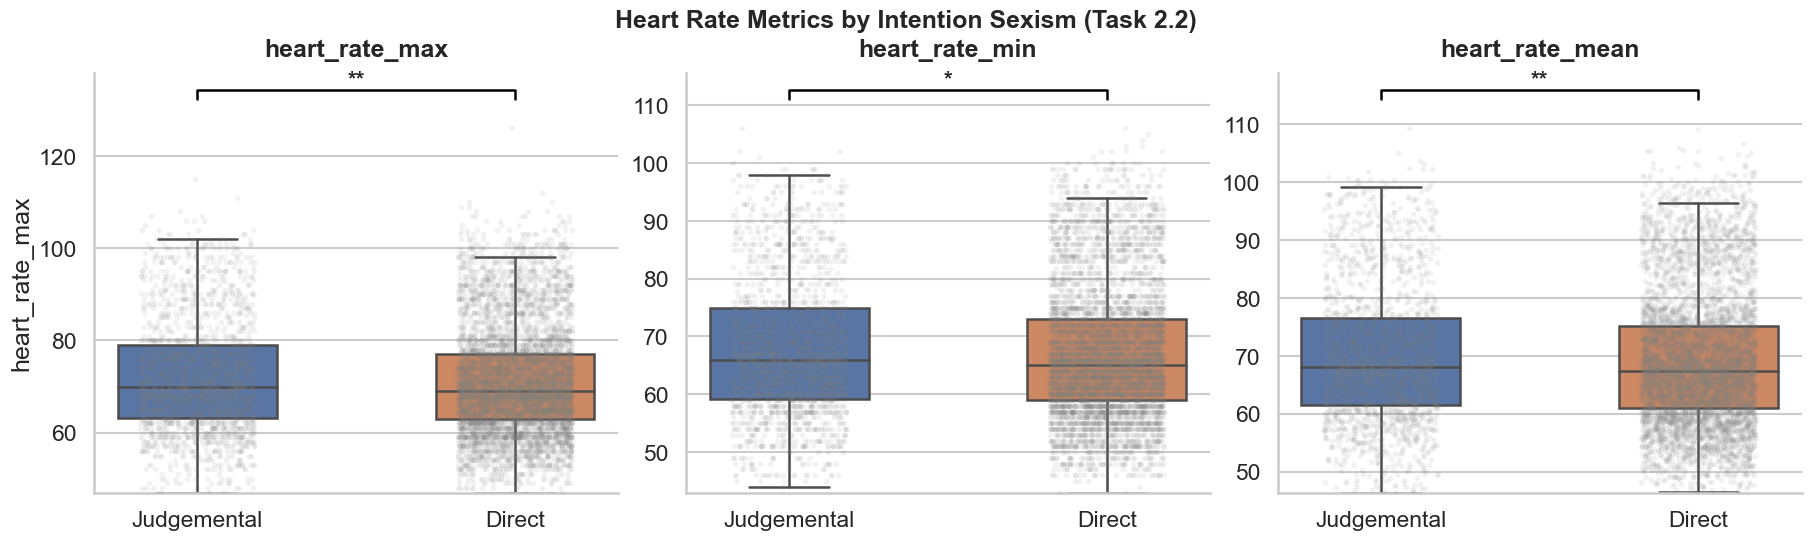

In [131]:
#Boxplots compared by task21_hard (sexism label) for the selected metrics, with significance annotations based on Mann-Whitney U test.
metrics = ['heart_rate_max', 'heart_rate_min', 'heart_rate_mean']
label_map = {0: "Judgemental",1: "Direct"}

plot_df = hr_df.copy()
plot_df["task22_label"] = plot_df["task22_hard"].map(label_map)
order = ["Judgemental", "Direct"]

#Plot
sns.set_theme(style="whitegrid", context="talk")
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)


def add_significance(ax, data, x_col, y_col, order):
    # Extract groups without NaNs
    g1 = data.loc[data[x_col] == order[0], y_col].dropna()
    g2 = data.loc[data[x_col] == order[1], y_col].dropna()

    if len(g1) < 2 or len(g2) < 2:
        return None

    #  Mann-Whitney U test
    stat, p = mannwhitneyu(g1, g2, alternative="two-sided")
    if p < 0.001:
        stars = "***"
    elif p < 0.01:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = "ns"

    y_max = data[y_col].dropna().max()
    y_min = data[y_col].dropna().min()
    h = (y_max - y_min) * 0.08 if y_max > y_min else 0.5
    y = y_max + h

   
    ax.plot([0, 0, 1, 1], [y, y+h*0.3, y+h*0.3, y], lw=1.8, c="black")
    ax.text(0.5, y+h*0.35, stars, ha="center", va="bottom", fontsize=16, fontweight="bold")
    ax.set_ylim(y_min, y + h*0.9)

    return p

for ax, m in zip(axes, metrics):
    sub = plot_df[["task22_label", m]].dropna()

    sns.boxplot(data=sub,x="task22_label",y=m,order=order,ax=ax,width=0.5,showfliers=False,linewidth=1.8)
    sns.stripplot(data=sub,x="task22_label",y=m,order=order,ax=ax,color="grey",alpha=0.1,size=4,jitter=0.18)

    add_significance(ax, sub, "task22_label", m, order)

    
    titles = {"reaction_time_s": "Reaction Time (s)",
        "blink_duration_ms": "Blink Duration (ms)",
        "fixations": "Fixation Count",
        "saccades": "Saccade Count"}.get(m, m)

    ax.set_title(titles, fontweight="bold", pad=12)
    ax.set_xlabel("")
    ax.set_ylabel(titles if ax == axes[0] else "")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Heart Rate Metrics by Intention Sexism (Task 2.2)", fontsize=18, fontweight="bold", y=1.05)
plt.show()

### Task 2.3 (Multilabel)

In [132]:
task23_classes = list(df["task23_hard"].iloc[0].keys())

tables_task23 = {}

for cls in task23_classes:
    
    hr_df[f"class_{cls}"] = hr_df["task23_hard"].apply(lambda x: x.get(cls, 0))
    
    table = compute_table(
        hr_df,
        group_col=f"class_{cls}",
        group_names=(0, 1),
        metrics=metrics
    )
    
    table.columns = ["Metric", "Absent", "Present", "p-value"]
    
    tables_task23[cls] = table

for t in task23_classes:
    print(f"Class {t}:\n")
    print(tables_task23[t])
    print("\n\n")

Class IDEOLOGICAL-INEQUALITY:

            Metric         Absent        Present p-value
0   heart_rate_max  71.51 ± 11.99  71.84 ± 12.06  0.2656
1   heart_rate_min  67.42 ± 11.49  67.18 ± 11.49  0.2959
2  heart_rate_mean  69.46 ± 11.67  69.47 ± 11.71  0.9161



Class MISOGYNY-NON-SEXUAL-VIOLENCE:

            Metric         Absent        Present  p-value
0   heart_rate_max  71.66 ± 12.03  71.10 ± 11.77   0.1159
1   heart_rate_min  67.45 ± 11.51  66.59 ± 11.29  0.0121*
2  heart_rate_mean  69.55 ± 11.70  68.82 ± 11.46  0.0343*



Class OBJECTIFICATION:

            Metric         Absent        Present p-value
0   heart_rate_max  71.65 ± 12.04  71.47 ± 11.92  0.5997
1   heart_rate_min  67.38 ± 11.47  67.30 ± 11.53  0.6811
2  heart_rate_mean  69.49 ± 11.69  69.40 ± 11.66  0.7009



Class SEXUAL-VIOLENCE:

            Metric         Absent        Present p-value
0   heart_rate_max  71.67 ± 12.06  71.14 ± 11.64  0.1611
1   heart_rate_min  67.40 ± 11.54  67.07 ± 11.19  0.2676
2  heart_rate_me

Contrary to our initial hypothesis, heart rate signals did not show significant differences between sexist and non-sexist content. This suggests that sexism detection is not primarily driven by physiological arousal but rather by cognitive processing mechanisms. While minor differences were observed in the intention detection task, their magnitude was small and inconsistent across categories, limiting their practical utility.

While eye-tracking features reveal clear differences in attention and cognitive processing, heart rate signals remain unchanged, indicating that users cognitively engage with sexist content without exhibiting strong physiological arousal.

## EEG

In [8]:
#How many users have valid EEG data per meme?
def count_valid_eeg_users(eeg_raw):
    if not isinstance(eeg_raw, dict):
        return 0
    return sum(1 for v in eeg_raw.values() if isinstance(v, dict))

df["EEG_valid_users"] = df["EEG_raw"].apply(count_valid_eeg_users)
df["EEG_valid_users"].describe()

count    3984.000000
mean        2.030622
std         0.172314
min         2.000000
25%         2.000000
50%         2.000000
75%         2.000000
max         3.000000
Name: EEG_valid_users, dtype: float64

In [34]:
#How many unique channels are there across all EEG recordings?
def extract_channels(eeg_raw):
    if not isinstance(eeg_raw, dict):
        return set()
    
    for user, feats in eeg_raw.items():
        if isinstance(feats, dict):
            return set([
                k.split("_")[2]  # Channel_X
                for k in feats.keys()
            ])
    return set()

channels = set()

for eeg in df["EEG_raw"]:
    channels |= extract_channels(eeg)

print("Channels:", sorted(channels))
print("Total channels:", len(channels))

Channels: ['0', '1', '10', '11', '12', '13', '14', '15', '2', '3', '4', '5', '6', '7', '8', '9']
Total channels: 16


In [36]:
#How many bands are there across all EEG recordings?
def extract_bands(eeg_raw):
    if not isinstance(eeg_raw, dict):
        return set()
    
    for user, feats in eeg_raw.items():
        if isinstance(feats, dict):
            return set([
                k.split("_")[-2]  # Alpha, Beta...
                for k in feats.keys()
            ])
    return set()

bands = set()

for eeg in df["EEG_raw"]:
    bands |= extract_bands(eeg)

print("Bands:", bands)
print("Total bands:", len(bands))

Bands: {'Gamma', 'Delta', 'Alpha', 'Beta', 'Theta'}
Total bands: 5


In [38]:
def flatten_eeg(eeg_raw):
    if not isinstance(eeg_raw, dict):
        return None
    
    all_users = []
    
    for user, feats in eeg_raw.items():
        if isinstance(feats, dict):
            all_users.append(feats)
    
    if len(all_users) == 0:
        return None
    
    df_users = pd.DataFrame(all_users)
    
    return df_users.mean().to_dict()

df["EEG_flat"] = df["EEG_raw"].apply(flatten_eeg)
df["EEG_flat"].head()

0    {'EXG_Channel_0_Alpha_power': -0.34555, 'EXG_C...
1    {'EXG_Channel_0_Alpha_power': 0.9471, 'EXG_Cha...
2    {'EXG_Channel_0_Alpha_power': 0.12860000000000...
3    {'EXG_Channel_0_Alpha_power': 0.0715, 'EXG_Cha...
4    {'EXG_Channel_0_Alpha_power': 0.37429999999999...
Name: EEG_flat, dtype: object

In [42]:
eeg_flat_df = df["EEG_flat"].apply(pd.Series)
df = pd.concat([df, eeg_flat_df], axis=1)

eeg_flat_df.shape

(3984, 80)

In [43]:
EEG_BANDS = ["Alpha", "Beta", "Delta", "Theta", "Gamma"]

def compute_band_means(row):
    result = {}
    
    for band in EEG_BANDS:
        cols = [c for c in eeg_flat_df.columns if f"_{band}_" in c]
        vals = row[cols].dropna()
        
        result[f"EEG_{band}_mean"] = vals.mean() if len(vals) > 0 else np.nan
    
    return pd.Series(result)

band_df = df.apply(compute_band_means, axis=1)
df = pd.concat([df, band_df], axis=1)

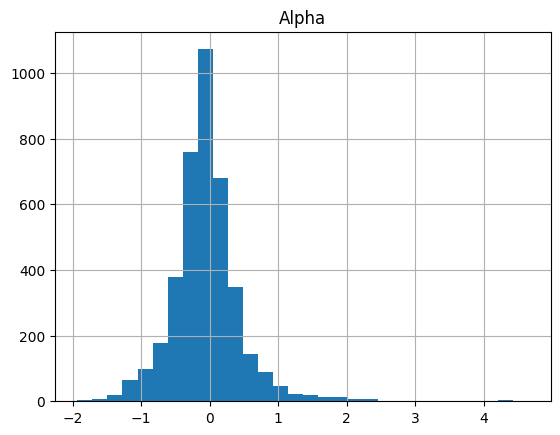

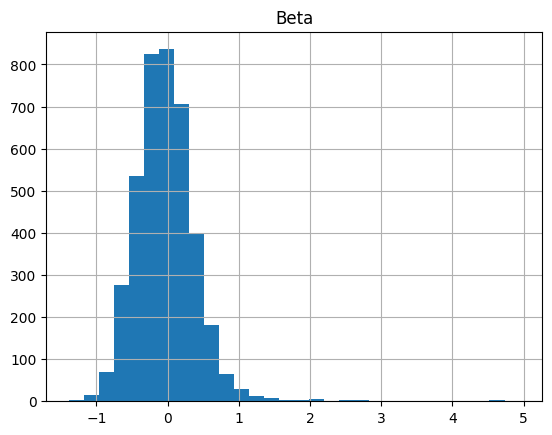

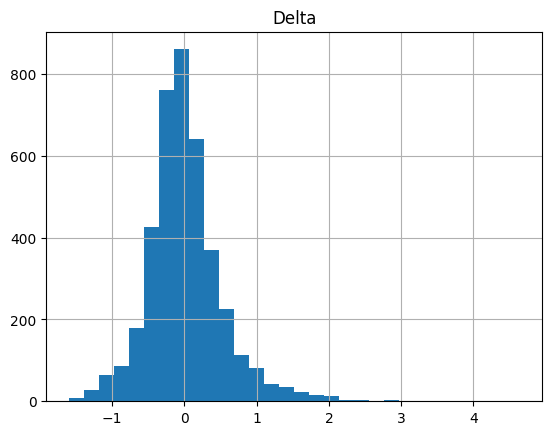

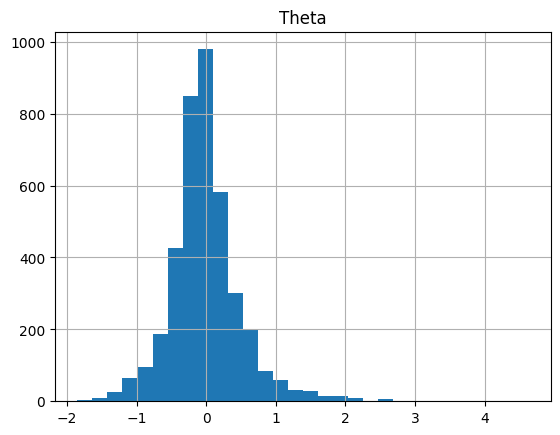

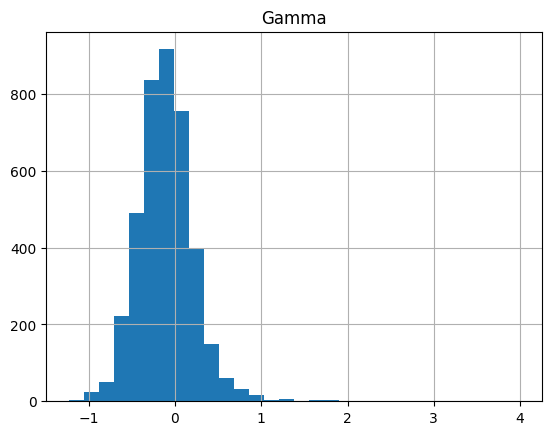

In [44]:
for band in EEG_BANDS:
    df[f"EEG_{band}_mean"].hist(bins=30)
    plt.title(band)
    plt.show()

In [49]:
df["beta_alpha"] = df["EEG_Beta_mean"] / (df["EEG_Alpha_mean"])
df["theta_alpha"] = df["EEG_Theta_mean"] / (df["EEG_Alpha_mean"])
df["gamma_beta"] = df["EEG_Gamma_mean"] / (df["EEG_Beta_mean"])

df.head()

,id,lang,text,image_file,split,ET_raw,HR_raw,EEG_raw,task21_hard,task21_valid_hard,...,EXG_Channel_9_Gamma_power,EXG_Channel_9_Theta_power,EEG_Alpha_mean,EEG_Beta_mean,EEG_Delta_mean,EEG_Theta_mean,EEG_Gamma_mean,beta_alpha,theta_alpha,gamma_beta
0,110887,es,A VECES QUISIERAIR/ALZUMBA www.facebook.com/Oi...,110887.jpeg,Train,"{'EN1': None, 'EN2': None, 'EN3': None, 'EN4':...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN4':...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN5':...",1,True,...,0.25595,-0.01350,-0.007325,0.435972,-0.079378,-0.268491,0.047144,-59.518345,36.654010,0.108135
1,110466,es,Se necesita cuidadora para adulto mayor.... fo...,110466.jpeg,Train,"{'EN1': None, 'EN2': None, 'EN3': None, 'EN4':...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN4':...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN5':...",1,True,...,0.50110,0.09475,0.123981,0.287212,-0.028747,0.035294,0.067363,2.316580,0.284670,0.234539
2,111269,es,tomboy como son el anime y manga pre to tomboy...,111269.jpeg,Train,"{'EN1': None, 'EN2': None, 'EN3': None, 'EN4':...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN4':...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN5':...",1,True,...,-0.09050,1.28450,0.419137,0.474569,0.603344,0.546509,0.038828,1.132251,1.303890,0.081818
3,110593,es,HOY QUIERO FELICITAR A TODAS LAS MUJERES DE ES...,110593.jpeg,Train,"{'EN1': None, 'EN2': None, 'EN3': None, 'EN4':...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN4':...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN5':...",0,True,...,-0.05485,-0.06805,0.181812,0.162559,1.281797,0.533828,0.005803,0.894105,2.936146,0.035698
4,110946,es,DUCHATE GUARRA GRACIAS memegenerator.es,110946.jpeg,Train,"{'EN1': None, 'EN2': None, 'EN3': None, 'EN4':...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN4':...","{'EN1': None, 'EN2': None, 'EN3': None, 'EN5':...",1,True,...,0.31450,0.71580,0.161622,0.159813,0.287362,0.203975,-0.046072,0.988805,1.262051,-0.288287


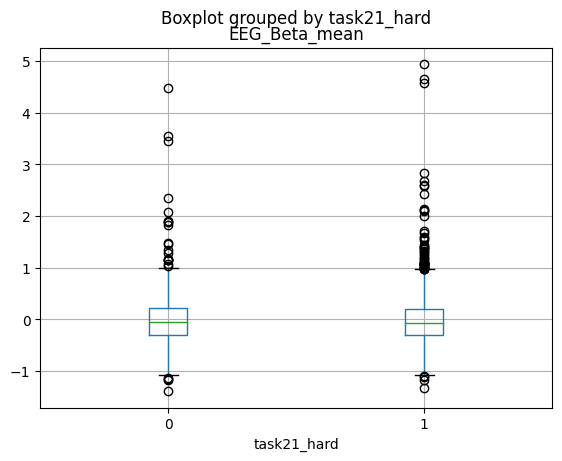

In [50]:
df.boxplot(column="EEG_Beta_mean", by="task21_hard")
plt.show()

In [51]:
df[["EEG_Beta_mean", "task21_soft"]].corr()
df[["beta_alpha", "task21_soft"]].corr()

,beta_alpha,task21_soft
beta_alpha,1.000000,0.017987
task21_soft,0.017987,1.000000


In [52]:
task23_soft_df = df["task23_soft"].apply(pd.Series)

for col in task23_soft_df.columns:
    print(col, df["beta_alpha"].corr(task23_soft_df[col]))

IDEOLOGICAL-INEQUALITY 0.0008475207910104685
MISOGYNY-NON-SEXUAL-VIOLENCE 0.007083782225768866
OBJECTIFICATION 0.01460285102692904
SEXUAL-VIOLENCE 0.018517009060085427
STEREOTYPING-DOMINANCE 0.006260279500979969


<Axes: >

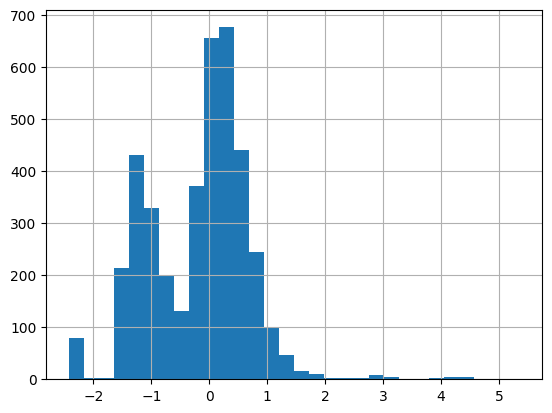

In [53]:
df["EXG_Channel_10_Beta_power"].hist(bins=30)

Model

In [63]:
features = eeg_flat_df.columns.tolist()

X = df[features].fillna(0)
y = df["task21_hard"]

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

preds = model.predict(X_test)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.45      0.07      0.11       276
           1       0.66      0.96      0.78       521

    accuracy                           0.65       797
   macro avg       0.55      0.51      0.45       797
weighted avg       0.59      0.65      0.55       797



In [68]:
importances = pd.Series(model.feature_importances_, index=features)
importances.sort_values(ascending=False).head(20)

EXG_Channel_8_Alpha_power     0.016378
EXG_Channel_9_Alpha_power     0.015241
EXG_Channel_6_Gamma_power     0.014395
EXG_Channel_9_Theta_power     0.014189
EXG_Channel_8_Theta_power     0.014147
EXG_Channel_12_Gamma_power    0.014006
EXG_Channel_0_Delta_power     0.013909
EXG_Channel_8_Delta_power     0.013723
EXG_Channel_9_Delta_power     0.013700
EXG_Channel_12_Theta_power    0.013669
EXG_Channel_14_Delta_power    0.013649
EXG_Channel_3_Delta_power     0.013634
EXG_Channel_3_Alpha_power     0.013628
EXG_Channel_2_Delta_power     0.013621
EXG_Channel_13_Delta_power    0.013599
EXG_Channel_4_Delta_power     0.013450
EXG_Channel_3_Theta_power     0.013408
EXG_Channel_9_Beta_power      0.013403
EXG_Channel_12_Beta_power     0.013385
EXG_Channel_8_Gamma_power     0.013230
dtype: float64